In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
import tensorflow as tf

In [3]:
data=pd.read_csv("heart_disease_dataset_multiclass.csv")

In [4]:
data.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,Slope,CA,HeartDisease
0,67,Male,176,205,False,182,True,4.0,Upsloping,3,Severe Disease
1,57,Female,104,294,False,191,True,1.4,Flat,3,Moderate Risk
2,43,Female,102,297,False,155,False,1.0,Downsloping,2,Mild Risk
3,71,Female,93,243,False,88,True,1.1,Flat,3,High Risk
4,36,Male,171,255,False,78,False,6.0,Upsloping,1,High Risk


In [5]:
x=data.iloc[:,0:10]
y=data[["HeartDisease"]]

In [7]:
categorical_cols = ["Sex", "FastingBS", "ExerciseAngina", "Slope"]
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "CA"]

# Encode only categorical
label_encoders = {}
for column in categorical_cols:
    le = LabelEncoder()
    x[column] = le.fit_transform(x[column])
    label_encoders[column] = le

# Numeric columns stay as they are
x[numeric_cols] = x[numeric_cols]

In [8]:
x.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,Slope,CA
0,67,1,176,205,0,182,1,4.0,2,3
1,57,0,104,294,0,191,1,1.4,1,3
2,43,0,102,297,0,155,0,1.0,0,2
3,71,0,93,243,0,88,1,1.1,1,3
4,36,1,171,255,0,78,0,6.0,2,1


In [9]:
y_label=LabelEncoder()
Y=y_label.fit_transform(y)

c:\Users\Achintya Srivastawa\tf_env\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [10]:
Y[0:5]

array([4, 2, 1, 0, 0])

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,Y,test_size=0.25,random_state=0)

In [13]:
from sklearn.preprocessing import StandardScaler
st=StandardScaler()
x_train=st.fit_transform(x_train)
x_test=st.transform(x_test)
# Feature scaling shows a tremendous amount of increase in the accuracy

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU
from tensorflow.keras.layers import Dropout

In [15]:
classifier=Sequential()

In [16]:
classifier.add(Dense(units=10, activation='relu'))

In [17]:
classifier.add(Dense(units=5, activation='softmax'))

In [18]:
opt=tf.keras.optimizers.Adam(learning_rate=0.01) 

In [19]:
classifier.compile(optimizer="Adam", loss='sparse_categorical_crossentropy', metrics=['accuracy']) 

In [20]:
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [21]:
mh=classifier.fit(x_train,y_train,validation_split=0.33,epochs=1000,batch_size=10,callbacks=early_stopping)

Epoch 1/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3569 - loss: 1.4830 - val_accuracy: 0.4229 - val_loss: 1.3192
Epoch 2/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5016 - loss: 1.1786 - val_accuracy: 0.5969 - val_loss: 1.0205
Epoch 3/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6164 - loss: 0.9347 - val_accuracy: 0.6741 - val_loss: 0.8449
Epoch 4/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6604 - loss: 0.8126 - val_accuracy: 0.6918 - val_loss: 0.7602
Epoch 5/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6859 - loss: 0.7499 - val_accuracy: 0.7072 - val_loss: 0.7116
Epoch 6/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6947 - loss: 0.7110 - val_accuracy: 0.7258 - val_loss: 0.6806
Epoch 7/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7036 - loss: 0.6849 - val_accuracy: 0.7262 - val_loss: 0.6585
Epoch 8/1000
503/503 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7128 - loss: 0.6645 - 

In [22]:
mh.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

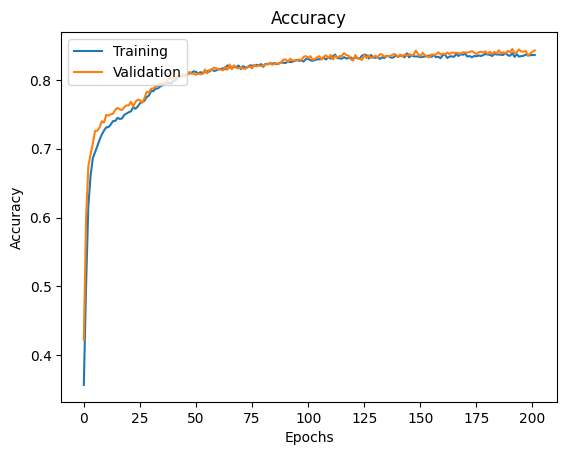

In [23]:
plt.plot(mh.history["accuracy"],label='Training')
plt.plot(mh.history["val_accuracy"],label='Validation')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='upper left')
plt.title("Accuracy")
plt.show()

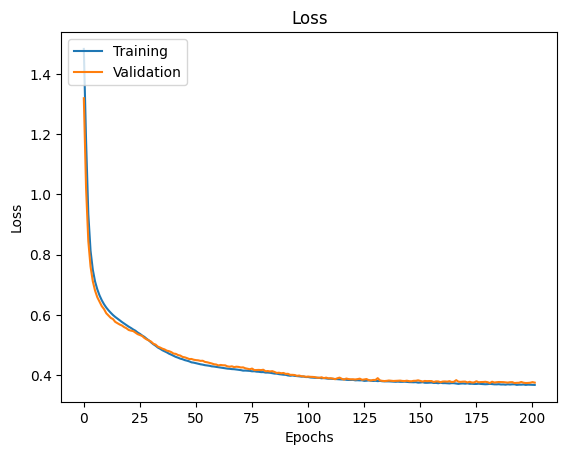

In [24]:
plt.plot(mh.history["loss"],label="Training")
plt.plot(mh.history["val_loss"],label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend(loc="upper left")
plt.show()

In [25]:
y_pred=classifier.predict(x_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [26]:
y_pred

array([[1.6931075e-01, 1.7358656e-03, 8.2889223e-01, 5.1325080e-11,
        6.1209961e-05],
       [5.5114677e-05, 7.9824162e-01, 2.0169163e-01, 1.1594099e-05,
        4.0026898e-11],
       [1.5493450e-06, 9.7463959e-01, 2.4299864e-02, 1.0590104e-03,
        5.4613215e-13],
       ...,
       [8.0898148e-01, 4.8291166e-10, 2.8684533e-03, 2.0635301e-23,
        1.8815003e-01],
       [7.4234641e-01, 2.1098436e-09, 2.6831238e-03, 1.2261198e-21,
        2.5497046e-01],
       [2.2331860e-04, 5.9714985e-01, 4.0256363e-01, 6.3221232e-05,
        3.2693825e-10]], dtype=float32)

In [27]:
y_pred_classes = np.argmax(y_pred, axis=1)

In [28]:
y_pred_classes

array([2, 1, 1, ..., 0, 0, 1])

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [30]:
y_test

array([2, 1, 1, ..., 0, 0, 1])

In [31]:
confusion_matrix(y_test,y_pred_classes)

array([[521,   0,  72,   0,  29],
       [  0, 493,  87,  30,   0],
       [ 95,  59, 724,   0,   0],
       [  0,  18,   0, 179,   0],
       [ 38,   0,   0,   0, 155]])

In [32]:
accuracy_score(y_test, y_pred_classes)

0.8288

In [33]:
input={
    "Age":45,
    "Sex":"Male",
    "RestingBP":145,
    'Cholesterol':233,
    "FastingBS":False,
    "MaxHR":133,
    "ExerciseAngina":False,
    "Oldpeak":1.5,
    "Slope":"Downsloping",
    "CA":0
}

In [34]:
input_df=pd.DataFrame([input])
input_df = pd.DataFrame([input])

# Encode categorical only
for column in categorical_cols:
    encoder = label_encoders[column]
    input_df[column] = encoder.transform(input_df[column])

# Keep numeric as-is
input_df[numeric_cols] = input_df[numeric_cols]

# Scale
input_df = st.transform(input_df)

In [35]:
Prediction=classifier.predict(input_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [36]:
Prediction[0]

array([5.3400803e-18, 3.8260236e-04, 3.8230791e-10, 9.9961734e-01,
       1.5977645e-27], dtype=float32)

In [37]:
y_pred_labels = np.argmax(Prediction, axis=1)  # index of max prob for each row
ans=y_pred_labels[0]

In [38]:
ans

np.int64(3)

In [39]:
if (ans==0):
    print("High Risk")
elif(ans==1):
    print("Moderate Risk")
elif(ans==2):
    print("Mild Risk")
elif(ans==3):
    print("No Disease")
else:
    print("Severe Disease")

No Disease


In [40]:
import joblib

# Save label encoders for each column
joblib.dump(label_encoders, "label_encoders.pkl")

# Save target encoder
joblib.dump(y_label, "y_label.pkl")

# Save scaler
joblib.dump(st, "scaler.pkl")

# Save model
classifier.save("heart_model.keras")